In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from matplotlib.ticker import MultipleLocator

In [2]:
## -- Load in fits from each case
## -- using the R=100 fits

## -- Case 1 results
l = np.load('./data/spec_fits_R100_case1.npz')
wavesR100 = l['waves']
wavehwsR100 = l['wavehws']
s1_fitsR100 = l['fits']
s1_errsR100 = l['errs']
s1_labels = l['labels']
del l

## -- Case 2
l = np.load('./data/spec_fits_R100_case2.npz')
wavesR100 = l['waves']
wavehwsR100 = l['wavehws']
s2_fitsR100 = l['fits']
s2_errsR100 = l['errs']
s2_labels = l['labels']
del l

## -- Case 3
l = np.load('data/spec_fits_R100_case3.npz') # 6 spots
s3_wavesR100 = l['waves']
s3_wavehwsR100 = l['wavehws']
s3_fitsR100 = l['fits']
s3_errsR100 = l['errs']
s3_labels = l['labels']
del l

## -- Case 4
l = np.load('./data/spec_fits_R100_case4.npz')
s4_wavesR100 = l['waves']
s4_wavehwsR100 = l['wavehws']
s4_fitsR100 = l['fits']
s4_errsR100 = l['errs']
s4_labels = l['labels']
del l

## -- calculate transit depths:
s1_depthsR100 = 1.e6*(s1_fitsR100[:,1]**2)
s1_deptherrsR100 = 1.e6*(2.*s1_fitsR100[:,1]*s1_errsR100[:,1])

s2_depthsR100 = 1.e6*(s2_fitsR100[:,1]**2)
s2_deptherrsR100 = 1.e6*(2.*s2_fitsR100[:,1]*s2_errsR100[:,1])

s3_depthsR100 = 1.e6*(s3_fitsR100[:,1]**2)
s3_deptherrsR100 = 1.e6*(2.*s3_fitsR100[:,1]*s3_errsR100[:,1])

s4_depthsR100 = 1.e6*(s4_fitsR100[:,1]**2)
s4_deptherrsR100 = 1.e6*(2.*s4_fitsR100[:,1]*s4_errsR100[:,1])

In [3]:
## -- plotting colors:
c1 = '#0652FF'
fc1 = '#316BEC'

c2 = 'green'
fc2 = '#13AF13'

c3 = '#6DADE2'
fc3 = '#A4CAEA'

c4 = '#FFAB0F'
fc4 = '#F5CA7E'

In [4]:
## -- compute vertical offsets relative to case 2
s1o = np.median(s2_depthsR100-s1_depthsR100)
s3o = np.median(s2_depthsR100-s3_depthsR100)
s4o = np.median(s2_depthsR100-s4_depthsR100)

## -- compute median transit depth uncertainties
meanerrsR100 = np.mean((s1_deptherrsR100, s2_deptherrsR100, s3_deptherrsR100, s4_deptherrsR100), axis=0)

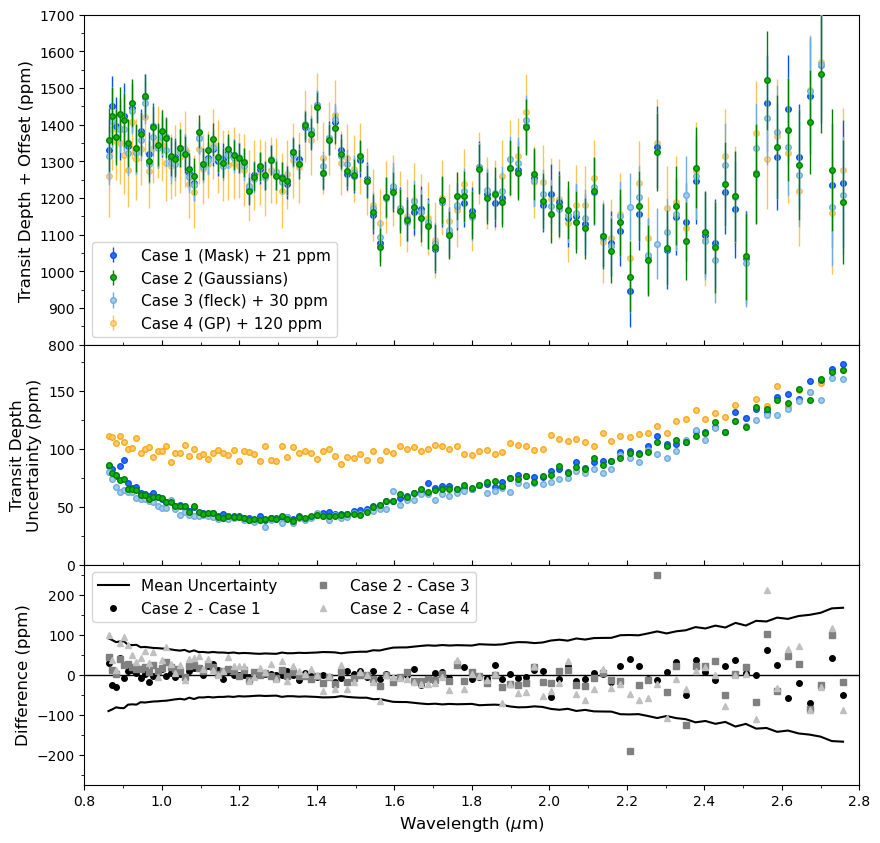

In [18]:
## Figure 3:

fig, ax = plt.subplots(figsize=(10,10), nrows=3, sharex=True, gridspec_kw={'height_ratios':[1.5,1,1]})
plt.subplots_adjust(hspace=0.)
ax[0].errorbar(wavesR100, s1_depthsR100+s1o, s1_deptherrsR100, ls='None', lw=1, marker='o', ms=4, c=c1, mec=c1, mfc=fc1, zorder=5, label='Case 1 (Mask) + %.0f ppm'%(s1o))
ax[0].errorbar(wavesR100, s1_depthsR100+s1o, s1_deptherrsR100, ls='None', lw=1, marker='o', ms=4, c='white', zorder=4)

ax[0].errorbar(wavesR100, s2_depthsR100, s2_deptherrsR100, ls='None', lw=1, marker='o', ms=4, c=c2, mec=c2, mfc=fc2, zorder=20, label='Case 2 (Gaussians)')
ax[0].errorbar(wavesR100, s2_depthsR100, s2_deptherrsR100, ls='None', lw=1, marker='o', ms=4, c='white', zorder=19)

ax[0].errorbar(wavesR100, s3_depthsR100+s3o, s3_deptherrsR100, ls='None', lw=1, marker='o', ms=4, c=c3, mec=c3, mfc=fc3, zorder=10, label='Case 3 (fleck) + %.0f ppm'%(s3o))
ax[0].errorbar(wavesR100, s3_depthsR100+s3o, s3_deptherrsR100, ls='None', lw=1, marker='o', ms=4, c='white', zorder=9)

ax[0].errorbar(s4_wavesR100, s4_depthsR100+s4o, s4_deptherrsR100, ls='None', lw=1, marker='o', ms=4, c=c4, mec=c4, mfc=fc4, alpha=0.7, zorder=1, label='Case 4 (GP) + %.0f ppm'%(s4o))
ax[0].set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
ax[0].set_ylabel(r'Transit Depth + Offset (ppm)', fontsize=12)
ax[0].legend(loc='lower left', fontsize=11, ncol=1)
ax[0].set_ylim(800,1700)
ax[0].yaxis.set_major_locator(MultipleLocator(100))
ax[0].yaxis.set_minor_locator(MultipleLocator(50))
ax[0].xaxis.set_major_locator(MultipleLocator(0.2))
ax[0].xaxis.set_minor_locator(MultipleLocator(0.1))
ax[0].tick_params(axis='x', which='both', direction='in')


ax[1].plot(wavesR100, s1_deptherrsR100, ls='None', lw=1, marker='o', ms=4, c=c1, mec=c1, mfc=fc1, zorder=5, label='Case 1 (Mask)')
ax[1].plot(wavesR100, s2_deptherrsR100, ls='None', lw=1, marker='o', ms=4, c=c2, mec=c2, mfc=fc2, zorder=20, label='Case 2 (Gaussians)')
ax[1].plot(wavesR100, s3_deptherrsR100, ls='None', lw=1, marker='o', ms=4, c=c3, mec=c3, mfc=fc3, zorder=10, label='Case 3 (fleck)')
ax[1].plot(s4_wavesR100, s4_deptherrsR100, ls='None', lw=1, marker='o', ms=4, c=c4, mec=c4, mfc=fc4, zorder=1, label='Case 4 (GP)')
ax[1].set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
ax[1].set_ylabel('Transit Depth\n'+'Uncertainty (ppm)', fontsize=12)
ax[1].set_ylim(0,190)
ax[1].yaxis.set_major_locator(MultipleLocator(50))
ax[1].yaxis.set_minor_locator(MultipleLocator(25))
ax[1].xaxis.set_major_locator(MultipleLocator(0.2))
ax[1].xaxis.set_minor_locator(MultipleLocator(0.1))
ax[1].tick_params(axis='x', which='both', direction='in')

ax[2].axhline(0., c='black', lw=1)
ax[2].plot(wavesR100, meanerrsR100, ls='solid', c='black', label='Mean Uncertainty')
ax[2].plot(wavesR100, -meanerrsR100, ls='solid', c='black')
ax[2].plot(wavesR100, (s2_depthsR100 - (s1_depthsR100+s1o)), ls='None', lw=1, marker='o', ms=4, c='black', zorder=1, label='Case 2 - Case 1')
ax[2].plot(wavesR100, (s2_depthsR100 - (s3_depthsR100+s3o)), ls='None', lw=1, marker='s', ms=4, c='gray', zorder=2, label='Case 2 - Case 3')
ax[2].plot(wavesR100, (s2_depthsR100 - (s4_depthsR100+s4o)), ls='None', lw=1, marker='^', ms=4, c='silver', zorder=2, label='Case 2 - Case 4')
ax[2].set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
ax[2].set_ylabel(r'Difference (ppm)', fontsize=12)
ax[2].legend(loc='upper left', fontsize=11, ncol=2)
ax[2].set_ylim(-275,275)
ax[2].set_xlim(0.8,2.8)
ax[2].yaxis.set_major_locator(MultipleLocator(100))
ax[2].yaxis.set_minor_locator(MultipleLocator(50))
ax[2].xaxis.set_major_locator(MultipleLocator(0.2))
ax[2].xaxis.set_minor_locator(MultipleLocator(0.1))

plt.savefig('./figures/Figure3.png', dpi=600, bbox_inches='tight')
plt.show()